# Задание 1: Иллюзия уверенности (Monte Carlo Dropout)
## Легенда
Вы разрабатываете систему компьютерного зрения для автопилота. Ваша модель должна распознавать объекты на дороге. Случилась неполадка: камеру залепило грязью (на вход пошел цифровой шум), но автопилот с вероятностью 99% заявил, что видит в этом шуме «Светофор», и резко затормозил. Ваша задача — внедрить систему оценки «Неопределенности» (Uncertainty), чтобы машина могла сказать: «Я не знаю, что это».


## 1 Модель





In [1]:
# импорт библиотек
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.models import vgg16
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

In [2]:
# Загружаем предобученную модель vgg16 из torchvision.models
model = vgg16(pretrained=True)
model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

## 2 Данные

In [3]:
# Загружаем картинку
image_dog = Image.open("smeshnaya_sobaka.jpg").convert('RGB')

# Определяем трансформации к изображению
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])

# Применяем
dog_tensor = transform(image_dog).unsqueeze(0)

In [4]:
noise_image = torch.randn(1, 3, 224, 224)

## 3 The Softmax Liar

In [5]:
# Функция для получения названия класса
def get_class_name(class_idx):
    import requests
    classes_url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
    classes = requests.get(classes_url).text.split('\n')
    return classes[class_idx] if class_idx < len(classes) else f"Class_{class_idx}"

# Обычное изображение
model.eval()
with torch.no_grad():
    output_dog = model(dog_tensor)
    prob_dog, class_dog = torch.max(
        torch.nn.functional.softmax(output_dog[0], dim=0), 0)

print(f"\nОбычное изображение:")
print(f"  Top-1 класс: {class_dog.item()} - {get_class_name(class_dog.item())}")
print(f"  Softmax вероятность: {prob_dog.item():.4f} ({prob_dog.item()*100:.2f}%)")

# Шумовое изображение
with torch.no_grad():
    output_noise = model(noise_image)
    prob_noise, class_noise = torch.max(
        torch.nn.functional.softmax(output_noise[0], dim=0), 0)

print(f"\nШумовое изображение:")
print(f"  Top-1 класс: {class_noise.item()} - {get_class_name(class_noise.item())}")
print(f"  Softmax вероятность: {prob_noise.item():.4f} ({prob_noise.item()*100:.2f}%)")


Обычное изображение:
  Top-1 класс: 180 - American Staffordshire terrier
  Softmax вероятность: 0.6828 (68.28%)

Шумовое изображение:
  Top-1 класс: 794 - shower curtain
  Softmax вероятность: 0.0882 (8.82%)


Модель с вероятностью 8.82% уверена, что шум - это объект.

## 4 Реализация MC Dropout

In [6]:
# Функция для MC Dropout предсказаний
def predict_with_uncertainty(model, image, n_passes=50):
    model.train()
    predictions = []

    with torch.no_grad():
        for _ in range(n_passes):
            output = model(image)
            probs = torch.nn.functional.softmax(output[0], dim=0)
            predictions.append(probs.cpu().numpy())

    predictions = np.array(predictions)
    mean_predictions = np.mean(predictions, axis=0)
    variance = np.var(predictions, axis=0)

    return mean_predictions, variance, predictions

# Анализ обычного изображения
print(f"\nАнализ обычного изображения")
dog_mean, dog_var, dog_all = predict_with_uncertainty(model, dog_tensor, 50)
dog_class = np.argmax(dog_mean)
dog_prob = dog_mean[dog_class]
dog_entropy = -np.sum(dog_mean * np.log(dog_mean + 1e-10))

print(f"  Top-1 класс (усредненный)   {dog_class} - {get_class_name(dog_class)}")
print(f"  Средняя вероятность         {dog_prob:.4f}")
print(f"  Энтропия                    {dog_entropy:.4f}")
print(f"  Неопределенность            {np.mean(dog_var):.6f}")

# Анализ шумового изображения
print(f"\nАнализ шумового изображения")
noise_mean, noise_var, noise_all = predict_with_uncertainty(model, noise_image, 50)
noise_top_class = np.argmax(noise_mean)
noise_top_prob = noise_mean[noise_top_class]
noise_entropy = -np.sum(noise_mean * np.log(noise_mean + 1e-10))

print(f"  Top-1 класс (усредненный)   {noise_top_class} - {get_class_name(noise_top_class)}")
print(f"  Средняя вероятность         {noise_top_prob:.4f}")
print(f"  Энтропия                    {noise_entropy:.4f}")
print(f"  Неопределенность            {np.mean(noise_var):.6f}")


Анализ обычного изображения
  Top-1 класс (усредненный)   180 - American Staffordshire terrier
  Средняя вероятность         0.6901
  Энтропия                    1.0301
  Неопределенность            0.000041

Анализ шумового изображения
  Top-1 класс (усредненный)   794 - shower curtain
  Средняя вероятность         0.0969
  Энтропия                    4.8653
  Неопределенность            0.000021


## 5 Расчет Энтропии

In [7]:
print(f"Энтропия обычного изображения: {dog_entropy:.4f}")
print(f"Энтропия шумового изображения: {noise_entropy:.4f}") # тупо шумовое изображение
print(f"Разница: {noise_entropy - dog_entropy:.4f}") # в 4 часа утра это показалось смешным

Энтропия обычного изображения: 1.0301
Энтропия шумового изображения: 4.8653
Разница: 3.8352


### Вопрос: Сравните значения Энтропии для нормального фото и для шума. Как этот показатель поможет автопилоту избежать аварии?

Без энтропии автопилот мог бы случайно классифицировать шум как объект и совершить опасный маневр. С энтропией - он "понимает", что не уверен, и переходит в безопасный режим, предотвращая потенциальную аварию.

In [8]:
# Логика принятия решения
entropy_threshold = 1.5

# If-Else логика
if dog_entropy < entropy_threshold:
    print(f"\nОбычное изображение: Уверенное предсказание - можно действовать")
else:
    print(f"\nОбычное изображение: ВЫСОКАЯ НЕОПРЕДЕЛЕННОСТЬ! Требуется проверка")

if noise_entropy < entropy_threshold:
    print(f"Шумовое изображение: Уверенное предсказание - можно действовать")
else:
    print(f"Шумовое изображение: ВЫСОКАЯ НЕОПРЕДЕЛЕННОСТЬ! Требуется ручное управление")



Обычное изображение: Уверенное предсказание - можно действовать
Шумовое изображение: ВЫСОКАЯ НЕОПРЕДЕЛЕННОСТЬ! Требуется ручное управление


# Задание 2: Детектив визуализации (Saliency vs Grad-CAM)

Легенда

Вы перешли в отдел дебаггинга моделей. Жалоба от клиента: «Ваша модель классификации животных (ImageNet) работает отлично, но иногда выдает совершенно абсурдные ответы на очевидных фото». Вам нужно визуализировать логику сети и найти причину.

## 1 Модель



In [9]:
!pip install captum

In [10]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.io import read_image
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import requests
from io import BytesIO

In [11]:
model = models.resnet18(pretrained=True)
model = model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## 2 Инструментарий

In [12]:
# Импорт Saliency и LayerGradCam, модуля captum.attr.visualization
from captum.attr import Saliency, LayerGradCam
from captum.attr import visualization as viz

## 3 Сравнение методов


In [13]:
# Загружаем картинку
image_bird = Image.open("ara.jpg").convert('RGB')

# Определяем трансформации к изображению
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])
# Применяем
tensor_bird = transform(image_bird).unsqueeze(0)

# Применяем функцию для получения названия класса из предыдущего задания
model.eval()
with torch.no_grad():
    output_tensor_bird = model(tensor_bird)
    prob_tensor_bird, class_tensor_bird = torch.max(torch.nn.functional.softmax(output_tensor_bird[0], dim=0), 0)

print(f"Предсказанный класс: {class_tensor_bird.item()} - {get_class_name(class_tensor_bird.item())}")

Предсказанный класс: 88 - macaw


/usr/local/lib/python3.12/dist-packages/captum/attr/_core/saliency.py:129: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)


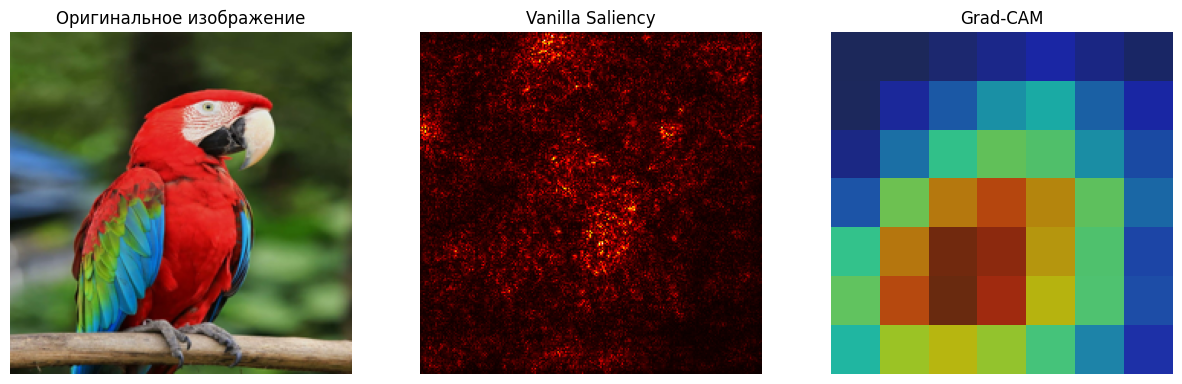

In [14]:
# Vanilla Saliency
saliency = Saliency(model)
saliency_map = saliency.attribute(tensor_bird, target=class_tensor_bird, abs=False)
saliency_map = saliency_map.squeeze().cpu().detach().numpy().transpose(1,2,0)
# Нормализация для визуализации
saliency_map = np.mean(np.abs(saliency_map), axis=2)

# Grad-CAM
grad_cam = LayerGradCam(model, model.layer4[-1])
grad_cam_map = grad_cam.attribute(tensor_bird, target=class_tensor_bird)
grad_cam_map = grad_cam_map.squeeze().cpu().detach().numpy()

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(np.array(image_bird.resize((224, 224))))
axes[0].set_title("Оригинальное изображение")
axes[0].axis('off')

axes[1].imshow(saliency_map, cmap='hot')
axes[1].set_title("Vanilla Saliency")
axes[1].axis('off')

axes[2].imshow(np.array(image_bird.resize((224, 224))))
axes[2].imshow(grad_cam_map, cmap='jet', alpha=0.6)
axes[2].set_title("Grad-CAM")
axes[2].axis('off')
plt.show()

### Вопрос
 Сравните визуально две полученные карты. Почему Saliency выглядит как «соль с перцем», а Grad-CAM выдает цельное тепловое пятно? Что именно они подсвечивают?

Vanilla Saliency вычисляет градиент выходного сигнала по каждому пикселю входного изображения. Это, по сути, карта чувствительности: насколько микроскопическое изменение каждого пикселя изменит ответ сети. Модель чувствительна к высокочастотным деталям, текстурам и границам. Мы видим множество разрозненных точек (шум), которые не формируют целостный семантический объект.

Grad-CAM использует градиенты, протекающие через последний сверточный слой (layer4[-1]). Он вычисляет веса для каждой карты признаков, а затем взвешивает эти карты и проецирует их обратно на размер входного изображения. Поскольку сверточные слои на глубоком уровне сети уже кодируют семантический объект, Grad-CAM показывает, какая область пространства заставила сеть активировать нейроны, отвечающие за  целевой класс. Это дает цельное, непрерывное пятно, указывающее на локализацию объекта.


## 4 Поиск аномалии (Следственный эксперимент)

Предсказанный класс: 782 - screen


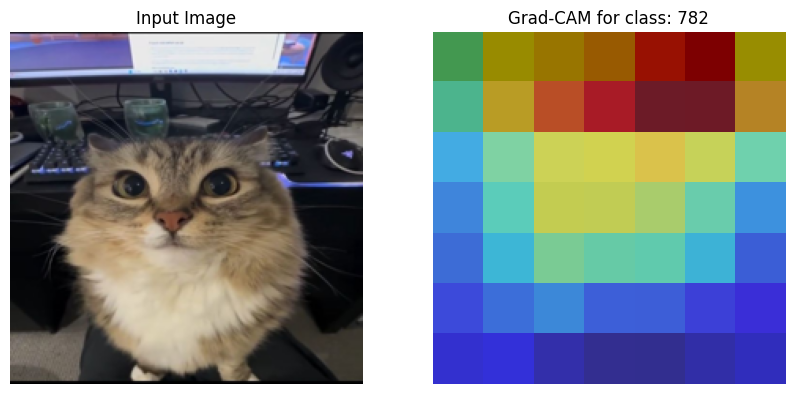

In [15]:
image_anomaly = Image.open("cat_comp.jpg").convert('RGB')
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])
tensor_anomaly = transform(image_anomaly).unsqueeze(0)

model.eval()
with torch.no_grad():
    output_anomaly_tensor = model(tensor_anomaly)
    prob_anomaly_tensor, class_anomaly_tensor = torch.max(torch.nn.functional.softmax(
        output_anomaly_tensor[0], dim=0), 0)

print(f"Предсказанный класс: {class_anomaly_tensor.item()} - {get_class_name(class_anomaly_tensor.item())}")

# Применяем Grad-CAM к предсказанному классу
grad_cam_map_anom = grad_cam.attribute(tensor_anomaly, target=class_anomaly_tensor)
grad_cam_map_anom = grad_cam_map_anom.squeeze().cpu().detach().numpy()

# Визуализация ошибки
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.imshow(np.array(image_anomaly.resize((224, 224))))
plt.title("Input Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(np.array(image_anomaly.resize((224, 224))))
plt.imshow(grad_cam_map_anom, cmap='jet', alpha=0.6)
plt.title(f"Grad-CAM for class: {class_anomaly_tensor}")
plt.axis('off')
plt.show()

### «Отчет об ошибке»

Предсказание модели: "tabby" - порода кошки (или "cat") в нормальной ситуации, но при наличии доминирующего объекта в виде монитора модель ошибочно выдает класс "screen" (экран). При применении Grad-CAM к классу "screen", тепловая карта не загорается на теле кошки, она ярко подсвечивает верхнюю часть картинки, где изображен монитор компьютера.
Модель проигнорировала доминирующий семантический признак (шерсть, морда), для нее наличие ярких очертаний монитора перевесило по весу признаки животного.
Модель классифицировала изображение не по главному субъекту действия (кошка), а по сильному признаку другого объекта (экран/монитор), попав в ловушку ложной корреляции.

Предсказанный класс: 281 - tabby


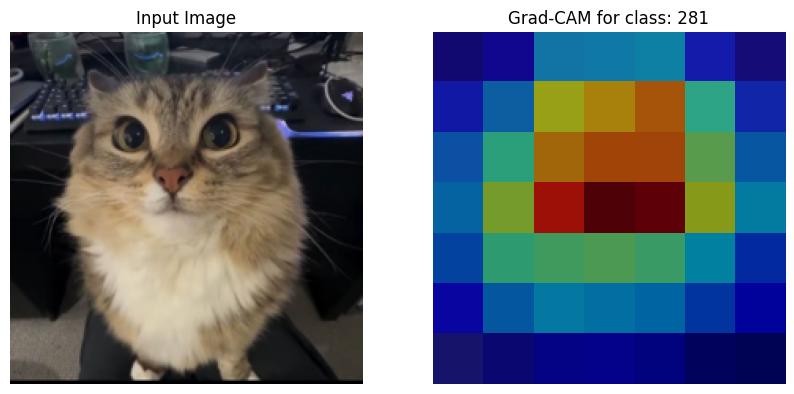

In [16]:
image_anomaly1 = Image.open("cat_comp1.jpg").convert('RGB')
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])
tensor_anomaly1 = transform(image_anomaly1).unsqueeze(0)

model.eval()
with torch.no_grad():
    output_anomaly_tensor1 = model(tensor_anomaly1)
    prob_anomaly_tensor1, class_anomaly_tensor1 = torch.max(
        torch.nn.functional.softmax(output_anomaly_tensor1[0], dim=0), 0)

print(f"Предсказанный класс: {class_anomaly_tensor1.item()} - {get_class_name(class_anomaly_tensor1.item())}")

# Применяем Grad-CAM к предсказанному классу
grad_cam_map_anom1 = grad_cam.attribute(tensor_anomaly1, target=class_anomaly_tensor1)
grad_cam_map_anom1 = grad_cam_map_anom1.squeeze().cpu().detach().numpy()

# Визуализация ошибки
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.imshow(np.array(image_anomaly1.resize((224, 224))))
plt.title("Input Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(np.array(image_anomaly1.resize((224, 224))))
plt.imshow(grad_cam_map_anom1, cmap='jet', alpha=0.6)
plt.title(f"Grad-CAM for class: {class_anomaly_tensor1}")
plt.axis('off')
plt.show()

Предсказанный класс: 242 - boxer


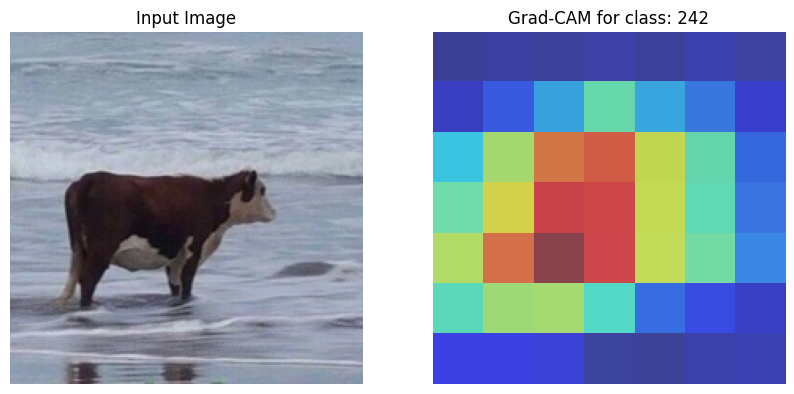

In [17]:
image_anomaly1 = Image.open("sad_cow.jpg").convert('RGB')
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])
tensor_anomaly1 = transform(image_anomaly1).unsqueeze(0)

model.eval()
with torch.no_grad():
    output_anomaly_tensor1 = model(tensor_anomaly1)
    prob_anomaly_tensor1, class_anomaly_tensor1 = torch.max(
        torch.nn.functional.softmax(output_anomaly_tensor1[0], dim=0), 0)

print(f"Предсказанный класс: {class_anomaly_tensor1.item()} - {get_class_name(class_anomaly_tensor1.item())}")

# Применяем Grad-CAM к предсказанному классу
grad_cam_map_anom1 = grad_cam.attribute(tensor_anomaly1, target=class_anomaly_tensor1)
grad_cam_map_anom1 = grad_cam_map_anom1.squeeze().cpu().detach().numpy()

# Визуализация ошибки
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.imshow(np.array(image_anomaly1.resize((224, 224))))
plt.title("Input Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(np.array(image_anomaly1.resize((224, 224))))
plt.imshow(grad_cam_map_anom1, cmap='jet', alpha=0.6)
plt.title(f"Grad-CAM for class: {class_anomaly_tensor1}")
plt.axis('off')
plt.show()

Предсказанный класс: 970 - alp


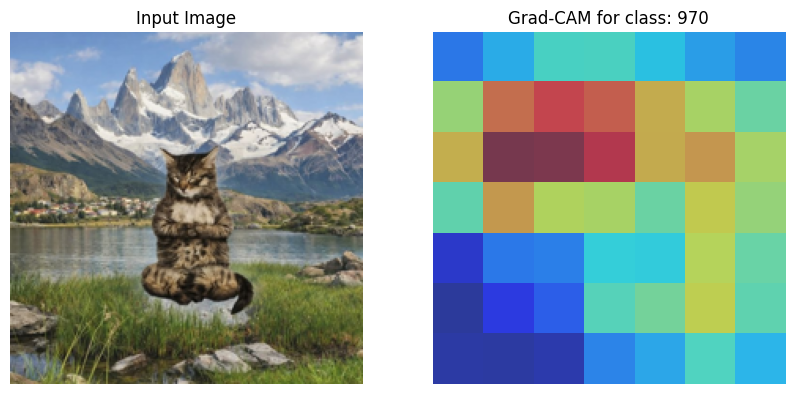

In [18]:
image_anomaly1 = Image.open("cat_meditation.jpg").convert('RGB')
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])
tensor_anomaly1 = transform(image_anomaly1).unsqueeze(0)

model.eval()
with torch.no_grad():
    output_anomaly_tensor1 = model(tensor_anomaly1)
    prob_anomaly_tensor1, class_anomaly_tensor1 = torch.max(
        torch.nn.functional.softmax(output_anomaly_tensor1[0], dim=0), 0)

print(f"Предсказанный класс: {class_anomaly_tensor1.item()} - {get_class_name(class_anomaly_tensor1.item())}")

# Применяем Grad-CAM к предсказанному классу
grad_cam_map_anom1 = grad_cam.attribute(tensor_anomaly1, target=class_anomaly_tensor1)
grad_cam_map_anom1 = grad_cam_map_anom1.squeeze().cpu().detach().numpy()

# Визуализация ошибки
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.imshow(np.array(image_anomaly1.resize((224, 224))))
plt.title("Input Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(np.array(image_anomaly1.resize((224, 224))))
plt.imshow(grad_cam_map_anom1, cmap='jet', alpha=0.6)
plt.title(f"Grad-CAM for class: {class_anomaly_tensor1}")
plt.axis('off')
plt.show()